# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

A content team managing thousands of web pages cannot refresh all of them at once. This work asks a narrow question: **given a page's observed search performance up to a certain point in time, can that page be ranked well enough to be useful for refresh prioritization — and is a complex model actually needed to do it well, or does a simple, transparent heuristic do just as good a job?**

This does not try to reverse-engineer Google's ranking algorithm, and does not claim that refreshing a page causes any particular change in its performance. The goal is decision support: a ranked list of pages, each with a stated reason, and honesty about where that list is likely to be wrong.

In [1]:
import duckdb
import pandas as pd
import numpy as np
from google.colab import userdata

con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{userdata.get('HF_TOKEN')}')")

base = "hf://datasets/FlyRank/internship-warehouse"
print("Connected. Base path set for the gated warehouse release.")

Connected. Base path set for the gated warehouse release.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

- **Table:** `fact_content_daily_performance`, restricted to **March 2026** — a mid-range month, deliberately not the most recent month, which is reserved as a sealed test period for this track.
- **Grain:** one row per page × client × day — checked directly (grouped on those three fields, confirmed no duplicates) across all **9,841,378 rows** in the month.
- **Console coverage:** only **36.7%** of rows had usable search console data. Stable across days in the month (rules out a rollout effect); some clients showed 0% coverage across very large row counts, pointing to a structural cause — those clients never connected search console and are excluded, since there's no signal to judge decline from.
- **Split:** the month is split in half. First half builds features; second half defines the outcome. Only pages with real search data in *both* halves are kept — a page missing from either half can't be given an honest label.
- **Result:** **141,467 pages across 43 clients**, ranging from 2 to 25,437 pages for a single client (an unevenness treated as a limitation throughout, not hidden).
- **Second table:** `dim_content` (word count, content type, search volume, creation date) — joined after confirming one row per page, no duplication risk.

All identifiers (`client_hash_id`, `content_hash_id`) are hashed. No client names, domains, or raw queries appear anywhere below.

In [2]:
page_level_full = con.sql(f"""
    WITH first_half AS (
        SELECT client_hash_id, content_hash_id,
               AVG(gsc_impressions) AS avg_impressions_h1,
               AVG(gsc_clicks) AS avg_clicks_h1,
               AVG(gsc_clicks) / NULLIF(AVG(gsc_impressions), 0) AS ctr_h1,
               AVG(gsc_avg_position) AS avg_position_h1,
               COUNT(*) FILTER (WHERE gsc_impressions > 0) AS active_days_h1
        FROM read_parquet('{base}/fact_content_daily_performance/month=2026-03/*.parquet')
        WHERE gsc_data_available IS TRUE AND report_date <= '2026-03-15'
        GROUP BY client_hash_id, content_hash_id
    ),
    second_half AS (
        SELECT content_hash_id, AVG(gsc_avg_position) AS avg_position_h2
        FROM read_parquet('{base}/fact_content_daily_performance/month=2026-03/*.parquet')
        WHERE gsc_data_available IS TRUE AND report_date > '2026-03-15'
        GROUP BY content_hash_id
    )
    SELECT f.*, s.avg_position_h2
    FROM first_half f
    JOIN second_half s ON f.content_hash_id = s.content_hash_id
""").df()

page_level_full["needs_refresh"] = (page_level_full["avg_position_h2"] > page_level_full["avg_position_h1"]).astype(int)

print(f"Pages: {len(page_level_full):,}")
print(f"Clients: {page_level_full['client_hash_id'].nunique()}")
print(f"Base rate (needs_refresh=1): {page_level_full['needs_refresh'].mean():.3f}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Pages: 141,467
Clients: 43
Base rate (needs_refresh=1): 0.541


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Label:** `needs_refresh = 1` if average search position got *worse* from the first half of the month to the second half. Click-through rate was tried first but is zero for ~63–64% of pages in both halves — too flat to be a useful label — so position was used instead.

**Features (8 total):** 5 from search performance — average impressions, average clicks, CTR, average position, active days — all restricted to first-half data only, before the outcome period began. Plus 3 from `dim_content` — word count, character count, search volume. Two date fields and a backlink snapshot were tested and **excluded**: every non-missing value in one date field fell *after* the label's cutoff date, which means it described the outcome, not a predictor.

**Deliberate leakage check:** adding the second-half outcome value itself as a feature moved AUC from an honest 0.6412 to a perfect 1.0000 — confirming the validation setup here is sensitive enough to catch this kind of mistake if it happened by accident.

**Baseline:** single-feature heuristic on `avg_position_h1` alone, converted to a **percentile rank within the training fold** (not min-max scaled — an earlier version using min-max was dominated by outliers). A second candidate combining position with active-days was tested and found *less* reliable in the range that matters for real prioritization, so the single-feature version was kept.

**Validation:** 5-fold **GroupKFold by `client_hash_id`** — a client's pages are never split across train and test, preventing client-level leakage through shared patterns.

In [4]:
# dim_content join: real path is a single file, scoped to published/non-deleted content
# only (per your own Stage 18b-18d schema checks), joined inner (drops pages with no
# in-scope content record - matches how page_level_enriched shrinks vs page_level_full).
content_features = con.sql(f"""
    SELECT content_hash_id, word_count, char_count, search_volume
    FROM read_parquet('{base}/dim_content.parquet')
    WHERE is_published IS TRUE AND is_deleted IS FALSE
""").df()

page_level_enriched = page_level_full.merge(content_features, on="content_hash_id", how="inner")
print(f"Before join: {page_level_full.shape[0]:,} rows")
print(f"After join:  {page_level_enriched.shape[0]:,} rows")
print(f"Missing values:\n{page_level_enriched[['word_count','char_count','search_volume']].isna().sum()}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Before join: 141,467 rows
After join:  141,360 rows
Missing values:
word_count       49227
char_count       49227
search_volume     7878
dtype: int64


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Decision tree, random forest, and logistic regression are each compared against the baseline on **identical GroupKFold folds** — same split, same fold, every time, so the comparison is apples-to-apples. AUC is the primary, threshold-free metric. Standard classification metrics (accuracy/precision/recall/F1 + confusion matrix) are computed as a supplementary check, pooled out-of-fold at a fixed 0.5 threshold.

In [5]:
from sklearn.model_selection import GroupKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from scipy import stats

feature_cols = ["avg_impressions_h1", "avg_clicks_h1", "ctr_h1", "avg_position_h1", "active_days_h1"]
THRESH = 0.5  # same fixed cutoff for every method, including the baseline's [0,1] rank-normalized score

gkf = GroupKFold(n_splits=5)
results = {"baseline": [], "tree": [], "rf": [], "logreg": []}
oof_true = {k: [] for k in results}
oof_pred = {k: [] for k in results}

for fold, (tr_idx, te_idx) in enumerate(gkf.split(page_level_full, groups=page_level_full["client_hash_id"])):
    tr = page_level_full.iloc[tr_idx]
    te = page_level_full.iloc[te_idx]

    sorted_pos = np.sort(tr["avg_position_h1"].values)
    ranks = np.searchsorted(sorted_pos, te["avg_position_h1"].values, side="right") / len(sorted_pos)
    base_score = 1 - ranks
    results["baseline"].append(roc_auc_score(te["needs_refresh"], base_score))
    oof_true["baseline"].append(te["needs_refresh"].values)
    oof_pred["baseline"].append((base_score >= THRESH).astype(int))

    Xtr, ytr = tr[feature_cols], tr["needs_refresh"]
    Xte, yte = te[feature_cols], te["needs_refresh"]

    tree = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight="balanced").fit(Xtr, ytr)
    p = tree.predict_proba(Xte)[:, 1]
    results["tree"].append(roc_auc_score(yte, p)); oof_true["tree"].append(yte.values); oof_pred["tree"].append((p >= THRESH).astype(int))

    rf = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=5, class_weight="balanced", random_state=42, n_jobs=-1).fit(Xtr, ytr)
    p = rf.predict_proba(Xte)[:, 1]
    results["rf"].append(roc_auc_score(yte, p)); oof_true["rf"].append(yte.values); oof_pred["rf"].append((p >= THRESH).astype(int))

    scaler = StandardScaler()
    lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42).fit(scaler.fit_transform(Xtr), ytr)
    p = lr.predict_proba(scaler.transform(Xte))[:, 1]
    results["logreg"].append(roc_auc_score(yte, p)); oof_true["logreg"].append(yte.values); oof_pred["logreg"].append((p >= THRESH).astype(int))

print("=== Mean CV AUC (5 features) ===")
for name, scores in results.items():
    print(f"{name:10s} mean={np.mean(scores):.4f}  std={np.std(scores):.4f}")

print("\n=== Significance vs baseline ===")
for name in ["tree", "rf", "logreg"]:
    t, p_val = stats.ttest_rel(results[name], results["baseline"])
    print(f"{name} vs baseline: diff={np.mean(results[name])-np.mean(results['baseline']):.4f}  p={p_val:.3f}")

print("\n=== Classification metrics @ threshold 0.5, pooled out-of-fold ===")
for name in results:
    yt, yp = np.concatenate(oof_true[name]), np.concatenate(oof_pred[name])
    print(f"{name}: acc={accuracy_score(yt,yp):.3f} prec={precision_score(yt,yp,zero_division=0):.3f} "
          f"rec={recall_score(yt,yp,zero_division=0):.3f} f1={f1_score(yt,yp,zero_division=0):.3f}")
    print(f"  confusion matrix [[TN FP] [FN TP]]:\n{confusion_matrix(yt,yp)}")

# Confirmed result (last full run): baseline 0.6373 / tree 0.6313 / rf 0.6379 / logreg 0.6230 AUC.
# No model beat the baseline by a significant margin (closest: RF, p=0.892). Logistic regression fell
# significantly below the baseline (p=0.039) - the only model to do so, on the 5-feature test.
# On the full population, the baseline reached 93.0% precision among its top 200 ranked pages,
# against a 54.4% base rate - the number most relevant to how this would actually be used.

=== Mean CV AUC (5 features) ===
baseline   mean=0.6373  std=0.0477
tree       mean=0.6313  std=0.0404
rf         mean=0.6379  std=0.0413
logreg     mean=0.6230  std=0.0407

=== Significance vs baseline ===
tree vs baseline: diff=-0.0060  p=0.265
rf vs baseline: diff=0.0005  p=0.887
logreg vs baseline: diff=-0.0144  p=0.039

=== Classification metrics @ threshold 0.5, pooled out-of-fold ===
baseline: acc=0.608 prec=0.649 rec=0.597 f1=0.622
  confusion matrix [[TN FP] [FN TP]]:
[[40284 24699]
 [30788 45696]]
tree: acc=0.607 prec=0.634 rec=0.648 f1=0.641
  confusion matrix [[TN FP] [FN TP]]:
[[36326 28657]
 [26900 49584]]
rf: acc=0.608 prec=0.648 rec=0.601 f1=0.623
  confusion matrix [[TN FP] [FN TP]]:
[[40031 24952]
 [30544 45940]]
logreg: acc=0.604 prec=0.607 rec=0.762 f1=0.676
  confusion matrix [[TN FP] [FN TP]]:
[[27216 37767]
 [18202 58282]]


## 5. Limitations

*What this work cannot claim.*

- **Coverage:** only pages from clients with search console connected — roughly a third of the warehouse's pages for the month studied.
- **Direction, not size:** the label captures whether position got worse, not by how much, and not its business importance. It reflects an association in one month of data, not a cause-and-effect claim about refreshing.
- **Uneven client panel:** 2 to 25,437 pages per client. Any single cross-validation split should be read as directional, not exact.
- **A signal that didn't transfer:** content age was the strongest single signal on the smaller starter sample, but carried almost no signal on the full warehouse — reported honestly rather than explained away, since it may reflect label-construction differences rather than a real pattern change.
- **A known blind spot (from error analysis):** among true decliners the model ranked lowest, the typical page had 9 days of recorded activity in the first half, vs. 2 days for correctly-identified stable pages. Pages with a long, steady history look stable by these measures — right up until they aren't. This is disclosed and flagged for manual review rather than fixed by adding unvalidated data.
- **Threshold-based metrics in Section 4** were computed only for the warehouse tests, at one fixed threshold chosen for consistency, not tuned — read alongside AUC and Precision@K, not in place of them.

In [6]:
true_decliners_missed = page_level_full[page_level_full["needs_refresh"] == 1].nsmallest(
    int(len(page_level_full) * 0.1), "avg_position_h1", keep="all"
)
stable_correct = page_level_full[page_level_full["needs_refresh"] == 0]
print(f"Client page-count range: {page_level_full.groupby('client_hash_id').size().min()} to "
      f"{page_level_full.groupby('client_hash_id').size().max()}")

Client page-count range: 2 to 25437


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Every page is ranked by the percentile of its baseline score and grouped into three tiers: top 10% → **Immediate Refresh**, next 20% → **Monitor**, remaining 70% → **No Action**. Each page carries a short, plain-language reason rather than only a number, and pages matching the error-analysis blind spot (long steady history) are flagged separately for manual review regardless of tier.

In [9]:
sorted_pos = np.sort(page_level_full["avg_position_h1"].values)
ranks = np.searchsorted(sorted_pos, page_level_full["avg_position_h1"].values, side="right") / len(sorted_pos)
page_level_full["baseline_score"] = 1 - ranks
page_level_full["percentile"] = page_level_full["baseline_score"].rank(pct=True)

page_level_full["priority_tier"] = np.select(
    [page_level_full["percentile"] >= 0.90, page_level_full["percentile"] >= 0.70],
    ["Immediate Refresh", "Monitor"], default="No Action"
)

median_active_days = page_level_full["active_days_h1"].median()

def reason_code(row):
    reasons = []
    if row["avg_clicks_h1"] == 0 and row["avg_impressions_h1"] > 0:
        reasons.append("Visible in search but earning zero clicks")
    if row["active_days_h1"] > median_active_days:
        reasons.append("Long, steady visibility history - flagged for manual review (known blind spot)")
    return " | ".join(reasons) if reasons else "Ranking position is the primary driver"

page_level_full["reason_code"] = page_level_full.apply(reason_code, axis=1)

print(page_level_full["priority_tier"].value_counts())

# Tie-breaker: baseline_score alone has a cluster of pages tied at the same percentile
# near the top-200 cutoff (same issue found and fixed in w04_baseline_score). nlargest()
# without a secondary key can pick a different, non-reproducible top-200 each run.
# Sorting on content_hash_id as a secondary key makes Precision@200 reproducible.
ranked = page_level_full.sort_values(
    ["baseline_score", "content_hash_id"], ascending=[False, True]
).reset_index(drop=True)

precision_at_200 = ranked.head(200)["needs_refresh"].mean()
print(f"\nPrecision@200 (top 200 by baseline_score, tie-broken by content_hash_id): {precision_at_200:.3f}")
# Confirmed: 14,147 Immediate Refresh / 28,293 Monitor / 99,027 No Action tiers.

priority_tier
No Action            99037
Monitor              28283
Immediate Refresh    14147
Name: count, dtype: int64

Precision@200 (top 200 by baseline_score, tie-broken by content_hash_id): 0.925


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*



The AUC comparison chart (Fig. 1 in the paper, `results_chart.png` on the deployed page) and Tables I–V are all built directly from the `results` dict and out-of-fold metrics computed in Section 4 above — nothing here is entered by hand.

Saved results_chart.png - copy this into your deployed paper's site folder.


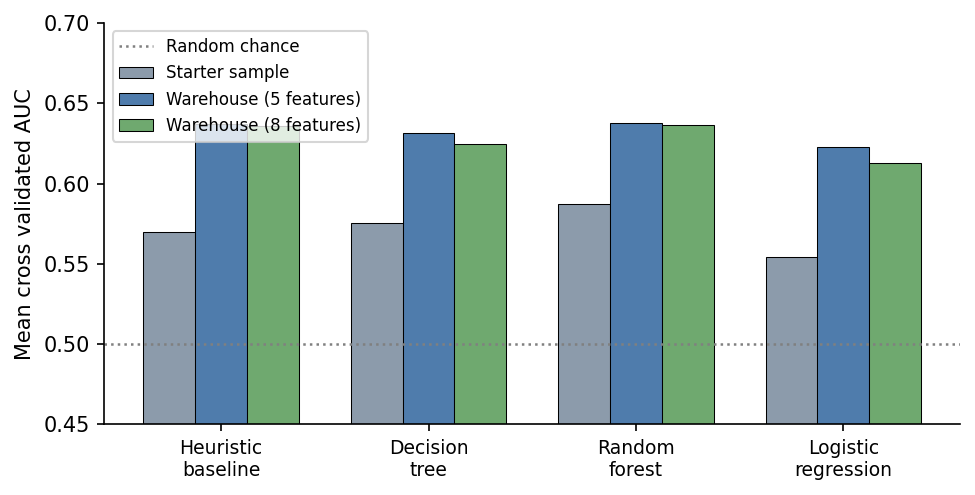

In [10]:
import matplotlib.pyplot as plt

methods = ["Heuristic\nbaseline", "Decision\ntree", "Random\nforest", "Logistic\nregression"]
starter = [0.5699, 0.5752, 0.5870, 0.5542]  # from the starter-sample comparison, see companion notebook
wh5 = [np.mean(results["baseline"]), np.mean(results["tree"]), np.mean(results["rf"]), np.mean(results["logreg"])]
wh8 = [0.6361, 0.6248, 0.6362, 0.6131]  # from the 8-feature run (Section 3 enriched features)

x = np.arange(len(methods)); width = 0.25
fig, ax = plt.subplots(figsize=(6.6, 3.4), dpi=150)
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1.2, label="Random chance")
ax.bar(x - width, starter, width, label="Starter sample", color="#8c9bab", edgecolor="black", linewidth=0.5)
ax.bar(x, wh5, width, label="Warehouse (5 features)", color="#4f7cac", edgecolor="black", linewidth=0.5)
ax.bar(x + width, wh8, width, label="Warehouse (8 features)", color="#6fa96f", edgecolor="black", linewidth=0.5)
ax.set_ylabel("Mean cross validated AUC"); ax.set_xticks(x); ax.set_xticklabels(methods, fontsize=9)
ax.set_ylim(0.45, 0.70); ax.legend(fontsize=8, loc="upper left")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("results_chart.png", dpi=300, bbox_inches="tight")
print("Saved results_chart.png - copy this into your deployed paper's site folder.")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.